# 🛏️ Time Series Challenge: Intelligent Sleep Apnea Screening
## Megawiz Health-Tech Data Challenge

**Student:** 602016_ปัฐธกร  
**Date:** 2026-05-05  
**Levels:** 1 (EDA & Signal Quality) · 2 (Event Detection) · 3 (Predictive Model + Dashboard)

---

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy import signal as scipy_signal
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, 'src')

# Set project root relative to notebook location
PROJECT_ROOT = os.path.normpath(os.path.join(os.getcwd(), '..', '..'))
DATA_ROOT = os.path.join(PROJECT_ROOT, 'data', 'raw')
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Data root    : {DATA_ROOT}')
print(f'Output dir   : {OUTPUT_DIR}')
print(f'Patients found: {len([d for d in os.listdir(DATA_ROOT) if d.startswith("patient_")])}')

Project root : c:\Users\Panuwit\Documents\GitHub\homework-time-series-tutorial
Data root    : c:\Users\Panuwit\Documents\GitHub\homework-time-series-tutorial\data\raw
Output dir   : c:\Users\Panuwit\Documents\GitHub\homework-time-series-tutorial\submissions\602016_ปัฐธกร\outputs
Patients found: 15


---
# 📊 Level 1: Time Series EDA & Signal Quality

**Tasks:**
1. อ่านไฟล์ EDF → โหลด signals เข้า DataFrame
2. ระบุและจัดการ sentinel values (511, 127) และ missing data
3. คำนวณ Signal Quality Index (SQI)
4. สร้าง multi-channel time-series visualization
5. วิเคราะห์ความสัมพันธ์ระหว่าง channels

## 1.1 Load EDF and Inspect Signal Metadata

In [2]:
from data_loader import load_patient, get_all_patient_dirs, CHANNEL_INFO, POSITION_MAP

# Load patient_001 as primary example
P1_DIR = os.path.join(DATA_ROOT, 'patient_001')
p1 = load_patient(P1_DIR)

print(f"Patient       : {p1['patient_id']}")
print(f"Start time    : {p1['start_datetime']}")
print(f"Duration      : {p1['duration_sec']/3600:.2f} hours ({p1['duration_sec']:.0f} s)")
print(f"Channels      : {list(p1['raw'].keys())}")
print()

# Channel metadata table
rows = []
for label, arr in p1['raw'].items():
    sr = p1['sample_rates'].get(label, '?')
    rows.append({'Channel': label, 'SR (Hz)': sr, 'Samples': len(arr),
                 'Raw Min': round(arr.min(), 2), 'Raw Max': round(arr.max(), 2)})
meta_df = pd.DataFrame(rows)
print(meta_df.to_string(index=False))

Patient       : patient_001
Start time    : 2066-12-19 21:34:30
Duration      : 6.55 hours (23590 s)
Channels      : ['Resp nasal', 'Resp thorax', 'Pulse', 'SaO2', 'Battery', 'Position', 'Acc x-axis', 'Acc y-axis', 'Acc z-axis']

    Channel  SR (Hz)  Samples  Raw Min  Raw Max
 Resp nasal    100.0  2359000  -100.00   100.00
Resp thorax     10.0   235900  -100.00   100.00
      Pulse      1.0    23590    25.00   511.00
       SaO2      1.0    23590    70.00   127.00
    Battery      1.0    23590  2512.00  3129.00
   Position      1.0    23590     1.00     9.00
 Acc x-axis     10.0   235900    -1.44     0.53
 Acc y-axis     10.0   235900    -1.15     1.12
 Acc z-axis     10.0   235900    -0.78     2.00


## 1.2 Sentinel Handling & Signal Quality Index (SQI)

In [3]:
from data_loader import compute_sqi, compute_stats

# SQI before and after sentinel removal
print("=== Signal Quality Index (SQI) — patient_001 ===")
sqi = p1['sqi']
for ch, q in sqi.items():
    bar = '█' * int(q * 30) + '░' * (30 - int(q * 30))
    sentinel_info = ''
    if ch == 'Pulse':
        n_sentinel = int(np.sum(p1['raw'][ch] >= 511))
        sentinel_info = f'  [sentinel=511, masked {n_sentinel:,} samples]'
    elif ch == 'SaO2':
        n_sentinel = int(np.sum(p1['raw'][ch] >= 127))
        sentinel_info = f'  [sentinel=127, masked {n_sentinel:,} samples]'
    print(f"  {ch:<15} {bar} {q*100:5.1f}%{sentinel_info}")

print()
print("=== Detailed Stats ===")
display(p1['stats'])

=== Signal Quality Index (SQI) — patient_001 ===
  Resp nasal      ██████████████████████████████ 100.0%
  Resp thorax     ██████████████████████████████ 100.0%
  Pulse           ████████████████████████████░░  95.6%  [sentinel=511, masked 1,049 samples]
  SaO2            ████████████████████████████░░  95.6%  [sentinel=127, masked 1,031 samples]
  Battery         ██████████████████████████████ 100.0%
  Position        ██████████████████████████████ 100.0%
  Acc x-axis      ██████████████████████████████ 100.0%
  Acc y-axis      ██████████████████████████████ 100.0%
  Acc z-axis      ██████████████████████████████ 100.0%

=== Detailed Stats ===


,channel,n_total,n_valid,n_missing,sqi,min,max,mean,std
0,Resp nasal,2359000,2359000,0,1.0000,-99.997,100.000,15.730,12.593
1,Resp thorax,235900,235900,0,1.0000,-99.997,100.000,0.517,9.970
2,Pulse,23590,22541,1049,0.9555,25.000,104.000,73.936,6.479
3,SaO2,23590,22559,1031,0.9563,70.000,99.000,92.169,4.199
4,Battery,23590,23590,0,1.0000,2512.000,3129.000,2704.761,139.353
5,Position,23590,23590,0,1.0000,1.000,9.000,3.730,1.160
6,Acc x-axis,235900,235900,0,1.0000,-1.435,0.525,0.077,0.185
7,Acc y-axis,235900,235900,0,1.0000,-1.153,1.122,0.107,0.623
8,Acc z-axis,235900,235900,0,1.0000,-0.776,2.000,0.616,0.452


In [4]:
# SQI across all patients
patient_dirs = get_all_patient_dirs(DATA_ROOT)
sqi_records = []
for pd_dir in patient_dirs:
    p = load_patient(pd_dir)
    row = {'patient_id': p['patient_id']}
    row.update({f'sqi_{ch}': round(q, 4) for ch, q in p['sqi'].items()})
    row['duration_hr'] = round(p['duration_sec'] / 3600, 2)
    sqi_records.append(row)

sqi_df = pd.DataFrame(sqi_records)
print("=== SQI Across 15 Patients ===")
display(sqi_df[['patient_id', 'duration_hr', 'sqi_SaO2', 'sqi_Pulse']].to_string(index=False))

=== SQI Across 15 Patients ===


' patient_id  duration_hr  sqi_SaO2  sqi_Pulse\npatient_001         6.55    0.9563     0.9555\npatient_002         7.14    0.9998     0.9998\npatient_003         9.28    0.9935     0.9917\npatient_004         7.50    0.9994     0.9995\npatient_005         8.86    0.9958     0.9958\npatient_006        10.47    0.9984     0.9981\npatient_007         8.11    0.9989     0.9989\npatient_008         3.96    0.9990     0.9990\npatient_009         6.78    0.9984     0.9983\npatient_010        10.70    0.9963     0.9960\npatient_011         6.47    0.9992     0.9991\npatient_012         6.26    0.9966     0.9965\npatient_013         9.61    0.8013     0.7982\npatient_014         7.95    0.9988     0.9988\npatient_015         7.99    0.9998     0.9998'

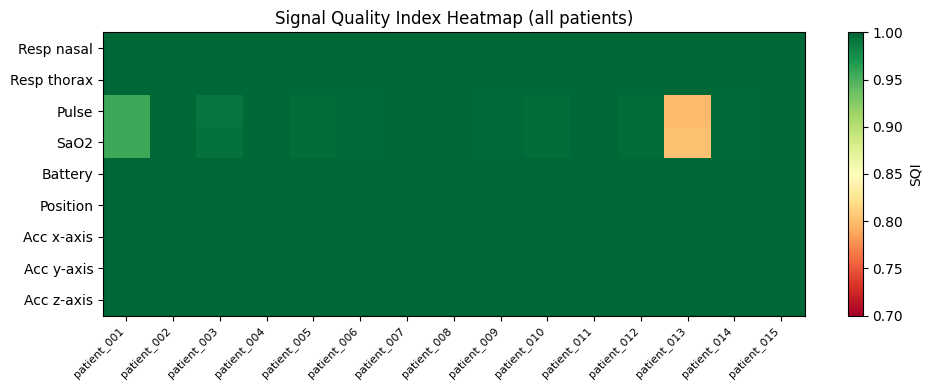

Saved: outputs/sqi_heatmap.png


In [5]:
# Visualize SQI heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sqi_cols = [c for c in sqi_df.columns if c.startswith('sqi_')]
heat_data = sqi_df.set_index('patient_id')[sqi_cols].values
im = ax.imshow(heat_data.T, aspect='auto', cmap='RdYlGn', vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(sqi_df)))
ax.set_xticklabels(sqi_df['patient_id'], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(sqi_cols)))
ax.set_yticklabels([c.replace('sqi_', '') for c in sqi_cols])
plt.colorbar(im, ax=ax, label='SQI')
ax.set_title('Signal Quality Index Heatmap (all patients)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sqi_heatmap.png'), dpi=150)
plt.show()
print("Saved: outputs/sqi_heatmap.png")

## 1.3 Multi-Channel Time-Series Visualization

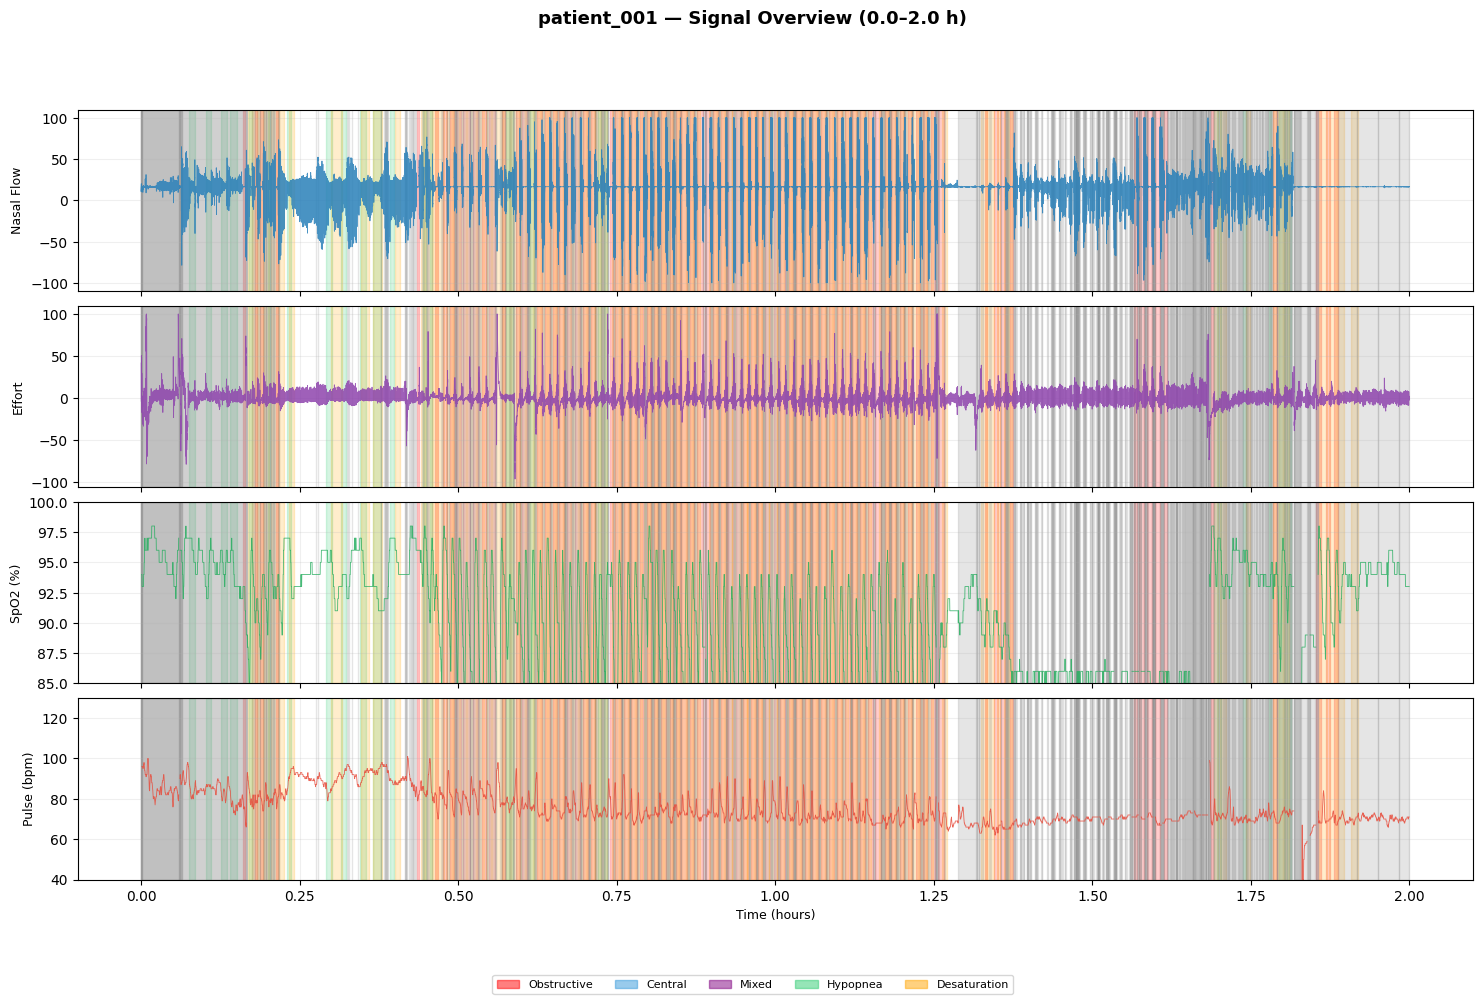

Saved: outputs/multichannel_patient001.png


In [6]:
def plot_multichannel(patient_data, t_start_sec=0, t_end_sec=3600, save_path=None):
    """AirView-style multi-channel sleep study plot."""
    sigs = patient_data['signals']
    srs = patient_data['sample_rates']
    events = patient_data['events']

    channels = [
        ('Resp nasal',  'Nasal Flow',  '#2980b9', (None, None)),
        ('Resp thorax', 'Effort',      '#8e44ad', (None, None)),
        ('SaO2',        'SpO2 (%)',    '#27ae60', (85, 100)),
        ('Pulse',       'Pulse (bpm)', '#e74c3c', (40, 130)),
    ]

    event_colors = {'OBSTR': 'red', 'CNTRL': '#3498db', 'MIXED': 'purple',
                    'HYPOP': '#2ecc71', 'DESAT': 'orange'}
    event_labels = {'OBSTR': 'Obstructive', 'CNTRL': 'Central', 'MIXED': 'Mixed',
                    'HYPOP': 'Hypopnea', 'DESAT': 'Desaturation'}

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f"{patient_data['patient_id']} — Signal Overview "
                 f"({t_start_sec/3600:.1f}–{t_end_sec/3600:.1f} h)",
                 fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(len(channels), 1, hspace=0.08)
    axes = [fig.add_subplot(gs[i]) for i in range(len(channels))]

    for ax, (ch, label, color, ylim) in zip(axes, channels):
        if ch not in sigs:
            continue
        arr = sigs[ch]
        sr = srs.get(ch, 1.0)
        s = int(t_start_sec * sr)
        e = int(t_end_sec * sr)
        t = np.arange(s, min(e, len(arr))) / sr / 3600.0  # hours
        v = arr[s:min(e, len(arr))]

        ax.plot(t, v, color=color, linewidth=0.6, alpha=0.85)
        ax.set_ylabel(label, fontsize=9)
        if ylim[0] is not None:
            ax.set_ylim(ylim)
        ax.tick_params(axis='x', labelbottom=False)
        ax.grid(alpha=0.2)

        # Overlay events
        if not events.empty:
            for _, ev in events.iterrows():
                if ev.end_sec < t_start_sec or ev.start_sec > t_end_sec:
                    continue
                ec = event_colors.get(ev.type, 'gray')
                x0 = max(ev.start_sec, t_start_sec) / 3600.0
                x1 = min(ev.end_sec, t_end_sec) / 3600.0
                ax.axvspan(x0, x1, alpha=0.20, color=ec)

    axes[-1].tick_params(axis='x', labelbottom=True)
    axes[-1].set_xlabel('Time (hours)', fontsize=9)

    # Legend
    patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
               for t, c in event_colors.items() for l in [event_labels[t]]]
    fig.legend(handles=[mpatches.Patch(color=c, alpha=0.5, label=event_labels[t])
                        for t, c in event_colors.items()],
               loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.01))

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Plot first 2 hours of patient_001
plot_multichannel(p1, t_start_sec=0, t_end_sec=7200,
                  save_path=os.path.join(OUTPUT_DIR, 'multichannel_patient001.png'))
print("Saved: outputs/multichannel_patient001.png")

## 1.4 Channel Correlation Analysis

In [7]:
from data_loader import signals_to_1hz

# Downsample all channels to 1 Hz for correlation analysis
df_1hz = signals_to_1hz(p1['signals'], p1['sample_rates'])
print(f"1 Hz DataFrame shape: {df_1hz.shape}")
display(df_1hz.head())

1 Hz DataFrame shape: (23590, 10)


,time_sec,Resp nasal,Resp thorax,Pulse,SaO2,Battery,Position,Acc x-axis,Acc y-axis,Acc z-axis
0,0.0,14.703960,16.380560,NaN,NaN,3122.0,9.0,-0.975686,0.020392,0.089412
1,1.0,16.473732,23.561456,NaN,NaN,3122.0,9.0,-0.952157,-0.156863,0.144314
2,2.0,16.223911,22.073701,NaN,NaN,3074.0,8.0,-0.916078,0.406275,-0.083137
3,3.0,16.648722,17.492943,NaN,94.0,3119.0,8.0,-0.912941,0.404706,-0.062745
4,4.0,16.535256,0.779736,96.0,94.0,3077.0,9.0,-0.988235,0.125490,0.111373


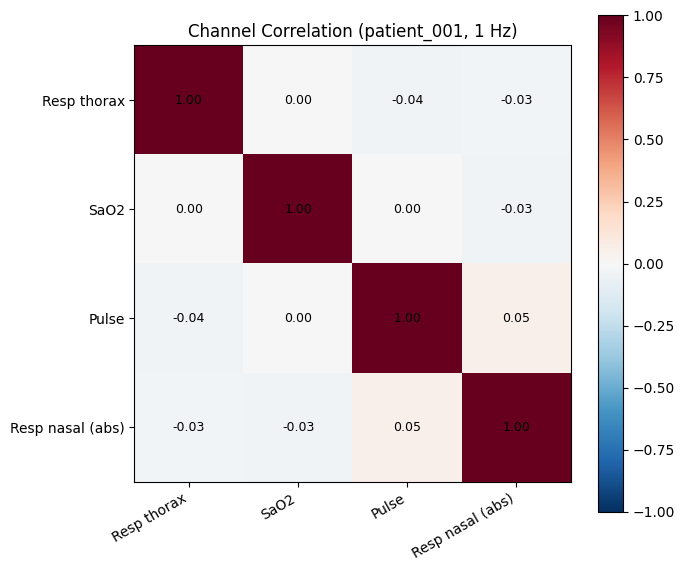

Saved: outputs/correlation_matrix.png


In [8]:
# Correlation matrix of physiological signals
corr_cols = ['Resp nasal', 'Resp thorax', 'SaO2', 'Pulse']
corr_data = df_1hz[corr_cols].copy()
# Use absolute value for nasal flow (envelope)
corr_data['Resp nasal (abs)'] = corr_data['Resp nasal'].abs()
corr_data = corr_data.drop(columns=['Resp nasal'])

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=30, ha='right')
ax.set_yticks(range(len(corr_matrix)))
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title('Channel Correlation (patient_001, 1 Hz)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix.png'), dpi=150)
plt.show()
print("Saved: outputs/correlation_matrix.png")

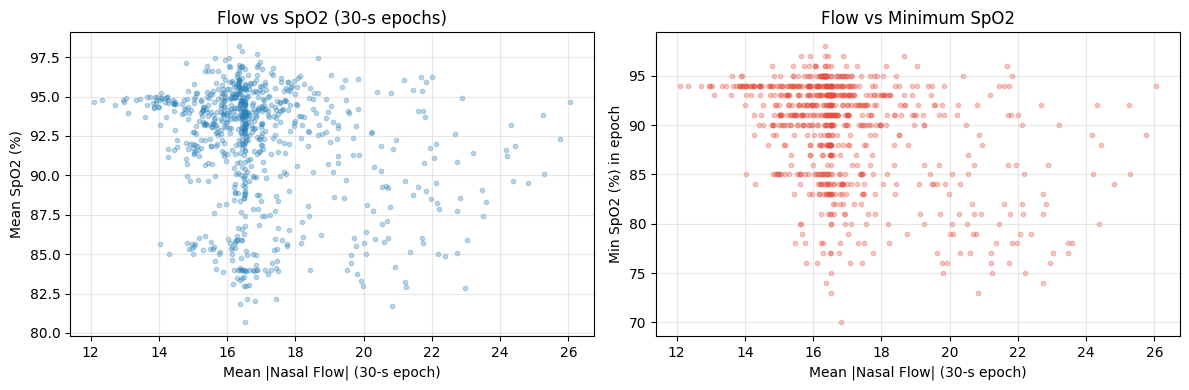

In [9]:
# SpO2 drop vs Nasal Flow — scatter (30-second epoch means)
epoch = 30  # seconds
n_ep = len(df_1hz) // epoch

ep_means = []
for i in range(n_ep):
    block = df_1hz.iloc[i*epoch:(i+1)*epoch]
    ep_means.append({
        'flow_abs_mean': block['Resp nasal'].abs().mean(),
        'spo2_mean': block['SaO2'].mean(),
        'spo2_min': block['SaO2'].min(),
    })
ep_df = pd.DataFrame(ep_means).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(ep_df['flow_abs_mean'], ep_df['spo2_mean'], alpha=0.3, s=10, color='#2980b9')
axes[0].set_xlabel('Mean |Nasal Flow| (30-s epoch)')
axes[0].set_ylabel('Mean SpO2 (%)')
axes[0].set_title('Flow vs SpO2 (30-s epochs)')
axes[0].grid(alpha=0.3)

axes[1].scatter(ep_df['flow_abs_mean'], ep_df['spo2_min'], alpha=0.3, s=10, color='#e74c3c')
axes[1].set_xlabel('Mean |Nasal Flow| (30-s epoch)')
axes[1].set_ylabel('Min SpO2 (%) in epoch')
axes[1].set_title('Flow vs Minimum SpO2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'flow_spo2_scatter.png'), dpi=150)
plt.show()

## 1.5 Export Clean Dataset

In [10]:
# Export 1-Hz aligned clean data for patient_001
clean_path = os.path.join(OUTPUT_DIR, 'clean_data_patient001.csv')
df_1hz.to_csv(clean_path, index=False)
print(f"Saved clean data: {clean_path}  (shape: {df_1hz.shape})")

# SQI summary across all patients
sqi_path = os.path.join(OUTPUT_DIR, 'sqi_summary.csv')
sqi_df.to_csv(sqi_path, index=False)
print(f"Saved SQI summary: {sqi_path}")

print("\n=== Level 1 Complete ===")

Saved clean data: c:\Users\Panuwit\Documents\GitHub\homework-time-series-tutorial\submissions\602016_ปัฐธกร\outputs\clean_data_patient001.csv  (shape: (23590, 10))
Saved SQI summary: c:\Users\Panuwit\Documents\GitHub\homework-time-series-tutorial\submissions\602016_ปัฐธกร\outputs\sqi_summary.csv

=== Level 1 Complete ===


---
# 🔍 Level 2: Automated Event Detection

**Tasks:**
1. Baseline detection สำหรับ nasal flow
2. Apnea detector + Hypopnea detector + Desaturation detector
3. คำนวณ AHI, ODI, T90
4. เปรียบเทียบกับ Ground Truth
5. วิเคราะห์ตามท่านอน (Supine vs Non-supine)

## 2.1 Baseline & Envelope Visualization

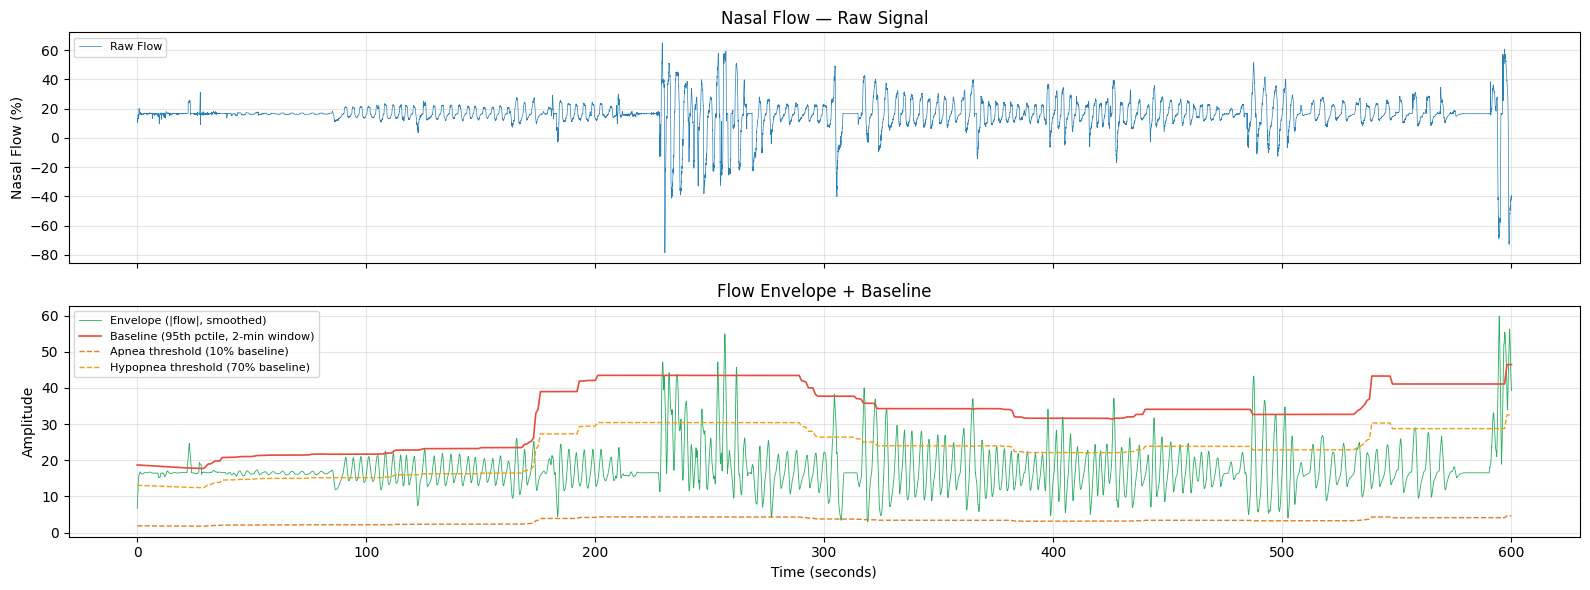

In [11]:
from event_detector import (
    compute_flow_envelope, compute_flow_baseline, compute_spo2_baseline,
    run_detector, events_to_dataframe, classify_severity
)

flow = p1['signals']['Resp nasal']
flow_sr = p1['sample_rates']['Resp nasal']

# Show first 10 minutes
n_show = int(600 * flow_sr)  # 10 minutes
t = np.arange(n_show) / flow_sr

envelope = compute_flow_envelope(flow, flow_sr)
baseline = compute_flow_baseline(envelope, flow_sr)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
axes[0].plot(t, flow[:n_show], color='#2980b9', lw=0.5, label='Raw Flow')
axes[0].set_ylabel('Nasal Flow (%)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_title('Nasal Flow — Raw Signal')

axes[1].plot(t, envelope[:n_show], color='#27ae60', lw=0.6, label='Envelope (|flow|, smoothed)')
axes[1].plot(t, baseline[:n_show], color='#e74c3c', lw=1.2, label='Baseline (95th pctile, 2-min window)')
axes[1].plot(t, baseline[:n_show] * 0.10, color='#e67e22', lw=1.0, ls='--', label='Apnea threshold (10% baseline)')
axes[1].plot(t, baseline[:n_show] * 0.70, color='#f39c12', lw=1.0, ls='--', label='Hypopnea threshold (70% baseline)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_title('Flow Envelope + Baseline')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'baseline_envelope.png'), dpi=150)
plt.show()

## 2.2 Run Full Event Detector on Patient 001

In [12]:
result = run_detector(p1)

print("=" * 55)
print(f"  Patient: {result['patient_id']}")
print("=" * 55)
print(f"  Recording duration : {result['recording_hours']:.2f} hours")
print(f"  AHI                : {result['ahi']:.2f} events/hr")
print(f"  AHI (Supine)       : {result['ahi_supine']:.2f} events/hr")
print(f"  AHI (Non-supine)   : {result['ahi_nonsupine']:.2f} events/hr")
print(f"  ODI                : {result['odi']:.2f} events/hr")
print(f"  Mean SpO2          : {result['mean_spo2']:.1f}%")
print(f"  Nadir SpO2         : {result['nadir_spo2']:.1f}%")
print(f"  T90 (SpO2<90%)     : {result['t90']:.1f}%")
print(f"  OSA Severity       : {result['severity']}")
print(f"  Apneas detected    : {result['n_apneas']}")
print(f"  Hypopneas detected : {result['n_hypopneas']}")
print(f"  Desaturations      : {result['n_desats']}")

  Patient: patient_001
  Recording duration : 6.55 hours
  AHI                : 27.32 events/hr
  AHI (Supine)       : 36.68 events/hr
  AHI (Non-supine)   : 17.47 events/hr
  ODI                : 29.91 events/hr
  Mean SpO2          : 92.2%
  Nadir SpO2         : 70.0%
  T90 (SpO2<90%)     : 21.1%
  OSA Severity       : Moderate
  Apneas detected    : 0
  Hypopneas detected : 179
  Desaturations      : 196


## 2.3 Compare with Ground Truth

In [13]:
from data_loader import ground_truth_ahi

gt_events = p1['events']
gt_ahi = ground_truth_ahi(gt_events, p1['duration_sec'])

# Ground truth counts
gt_counts = gt_events[gt_events['type'].isin(['OBSTR','CNTRL','MIXED','UNCLS','HYPOP'])]['type'].value_counts()

print("=" * 50)
print("         Ground Truth vs Our Detector")
print("=" * 50)
print(f"  GT AHI         : {gt_ahi:.2f}")
print(f"  Detected AHI   : {result['ahi']:.2f}")
print(f"  AHI Error      : {abs(gt_ahi - result['ahi']):.2f} events/hr")
print()
print("  Ground Truth event counts:")
for t, c in gt_counts.items():
    print(f"    {t:8s}: {c}")

         Ground Truth vs Our Detector
  GT AHI         : 45.48
  Detected AHI   : 27.32
  AHI Error      : 18.16 events/hr

  Ground Truth event counts:
    OBSTR   : 172
    HYPOP   : 91
    MIXED   : 31
    CNTRL   : 4


In [14]:
# AHI comparison all patients
patient_dirs = get_all_patient_dirs(DATA_ROOT)
comparison_rows = []

for pd_dir in patient_dirs:
    p = load_patient(pd_dir)
    res = run_detector(p)
    gt_ahi_val = ground_truth_ahi(p['events'], p['duration_sec'])
    comparison_rows.append({
        'patient_id': p['patient_id'],
        'GT AHI': round(gt_ahi_val, 2),
        'Detected AHI': res['ahi'],
        'AHI Error': round(abs(gt_ahi_val - res['ahi']), 2),
        'ODI': res['odi'],
        'Mean SpO2': res['mean_spo2'],
        'Nadir SpO2': res['nadir_spo2'],
        'T90 (%)': res['t90'],
        'Severity (GT)': classify_severity(gt_ahi_val),
        'Severity (Det)': res['severity'],
    })

comp_df = pd.DataFrame(comparison_rows)
mean_err = comp_df['AHI Error'].mean()
print(f"Mean AHI Error across 15 patients: {mean_err:.2f} events/hr")
display(comp_df)

Mean AHI Error across 15 patients: 7.04 events/hr


,patient_id,GT AHI,Detected AHI,AHI Error,ODI,Mean SpO2,Nadir SpO2,T90 (%),Severity (GT),Severity (Det)
0,patient_001,45.48,27.32,18.16,29.91,92.17,70.0,21.09,Severe,Moderate
1,patient_002,79.16,69.92,9.24,66.41,90.44,58.0,33.31,Severe,Severe
2,patient_003,13.15,12.72,0.43,7.00,94.90,79.0,8.56,Mild,Mild
3,patient_004,53.88,46.01,7.87,50.68,90.91,73.0,31.07,Severe,Severe
4,patient_005,10.49,7.33,3.16,4.74,94.16,80.0,1.27,Mild,Mild
5,patient_006,82.69,90.90,8.21,100.93,79.83,50.0,73.61,Severe,Severe
6,patient_007,37.36,30.58,6.78,16.27,94.11,71.0,4.89,Severe,Severe
7,patient_008,25.48,27.75,2.27,6.56,95.83,87.0,0.10,Moderate,Moderate
8,patient_009,27.73,10.77,16.96,7.82,92.98,82.0,8.62,Moderate,Mild
9,patient_010,8.51,8.04,0.47,1.31,97.57,81.0,0.27,Mild,Mild


## 2.4 Event Timeline Visualization

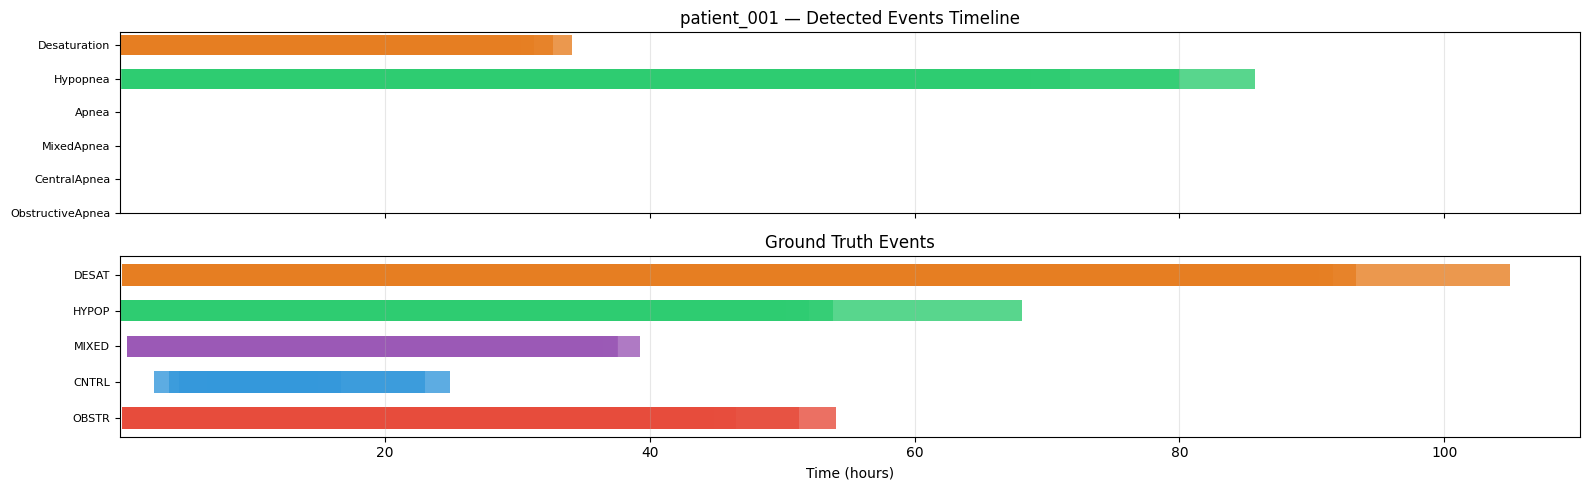

Saved: outputs/events_timeline.png


In [15]:
events_df = events_to_dataframe(result)

fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

# Our detected events
event_colors = {
    'ObstructiveApnea': '#e74c3c', 'CentralApnea': '#3498db',
    'MixedApnea': '#9b59b6', 'Apnea': '#e74c3c',
    'Hypopnea': '#2ecc71', 'Desaturation': '#e67e22',
}
y_map = {et: i for i, et in enumerate(event_colors)}

ax = axes[0]
for _, ev in events_df.iterrows():
    y = y_map.get(ev.event_type, 0)
    color = event_colors.get(ev.event_type, 'gray')
    ax.barh(y, ev.duration_sec, left=ev.start_sec / 3600, height=0.6, color=color, alpha=0.8)
ax.set_yticks(range(len(y_map)))
ax.set_yticklabels(list(y_map.keys()), fontsize=8)
ax.set_title(f'{result["patient_id"]} — Detected Events Timeline')
ax.grid(axis='x', alpha=0.3)

# Ground truth events
gt_colors = {'OBSTR': '#e74c3c', 'CNTRL': '#3498db', 'MIXED': '#9b59b6',
             'HYPOP': '#2ecc71', 'DESAT': '#e67e22'}
gt_y_map = {t: i for i, t in enumerate(gt_colors)}
gt_df = p1['events'][p1['events']['type'].isin(gt_colors)]

ax2 = axes[1]
for _, ev in gt_df.iterrows():
    y = gt_y_map.get(ev.type, 0)
    color = gt_colors.get(ev.type, 'gray')
    ax2.barh(y, ev.duration_sec, left=ev.start_sec / 3600, height=0.6, color=color, alpha=0.8)
ax2.set_yticks(range(len(gt_y_map)))
ax2.set_yticklabels(list(gt_y_map.keys()), fontsize=8)
ax2.set_title('Ground Truth Events')
ax2.set_xlabel('Time (hours)')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'events_timeline.png'), dpi=150)
plt.show()
print("Saved: outputs/events_timeline.png")

## 2.5 Positional Analysis


  Positional AHI — patient_001
  Supine AHI     : 36.68 events/hr
  Non-supine AHI : 17.47 events/hr
  → Positional OSA: YES (Supine/Non-supine ratio = 2.1x)

  Time per position:
    Upright   : 0.04 hr
    Prone     : 1.47 hr
    Left      : 0.37 hr
    Supine    : 3.44 hr
    Right     : 0.80 hr

=== Positional AHI Summary (all patients) ===


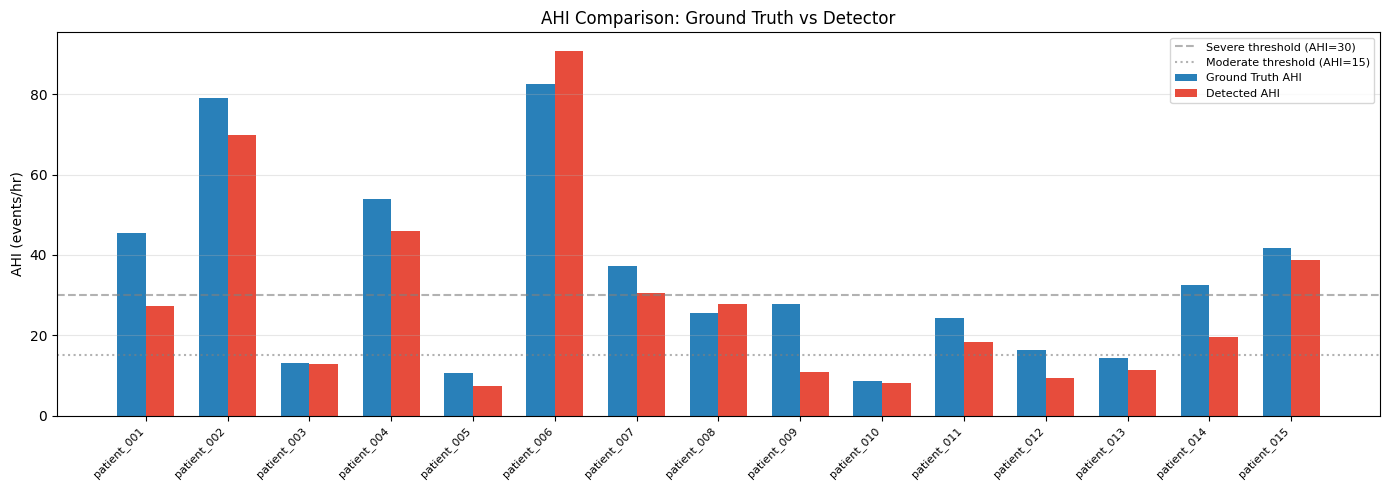

Saved: outputs/ahi_comparison.png


In [16]:
from event_detector import POSITION_MAP

print(f"\n{'='*50}")
print(f"  Positional AHI — {result['patient_id']}")
print(f"{'='*50}")
print(f"  Supine AHI     : {result['ahi_supine']:.2f} events/hr")
print(f"  Non-supine AHI : {result['ahi_nonsupine']:.2f} events/hr")

if result['ahi_nonsupine'] > 0:
    ratio = result['ahi_supine'] / result['ahi_nonsupine']
    if ratio > 2:
        print(f"  → Positional OSA: YES (Supine/Non-supine ratio = {ratio:.1f}x)")
    else:
        print(f"  → Positional OSA: NO (ratio = {ratio:.1f}x)")

print("\n  Time per position:")
for pos, hrs in result['position_hours'].items():
    if hrs > 0.01:
        print(f"    {pos:10s}: {hrs:.2f} hr")

# Summary: all patients positional AHI
print("\n=== Positional AHI Summary (all patients) ===")
pos_rows = []
for row in comparison_rows:
    pid = row['patient_id']
    pd_dir = os.path.join(DATA_ROOT, pid)
    # reuse loaded results from comparison_rows dict
    pass  # already computed above; just show comp_df

# Bar chart: AHI comparison per patient
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(comp_df))
width = 0.35
ax.bar(x - width/2, comp_df['GT AHI'], width, label='Ground Truth AHI', color='#2980b9')
ax.bar(x + width/2, comp_df['Detected AHI'], width, label='Detected AHI', color='#e74c3c')
ax.axhline(30, ls='--', color='gray', alpha=0.6, label='Severe threshold (AHI=30)')
ax.axhline(15, ls=':', color='gray', alpha=0.6, label='Moderate threshold (AHI=15)')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['patient_id'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('AHI (events/hr)')
ax.set_title('AHI Comparison: Ground Truth vs Detector')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ahi_comparison.png'), dpi=150)
plt.show()
print("Saved: outputs/ahi_comparison.png")

In [17]:
# Save AHI report
comp_df.to_csv(os.path.join(OUTPUT_DIR, 'ahi_report.csv'), index=False)

ahi_report_md = f"""# AHI Detection Report
Generated: 2026-05-05

## Summary
- Patients analyzed: {len(comp_df)}
- Mean AHI Error: **{comp_df['AHI Error'].mean():.2f}** events/hr
- Severity agreement: {(comp_df['Severity (GT)'] == comp_df['Severity (Det)']).sum()}/{len(comp_df)} patients

## Patient Results
"""
ahi_report_md += comp_df[['patient_id','GT AHI','Detected AHI','AHI Error',
                            'Mean SpO2','Nadir SpO2','T90 (%)','Severity (GT)','Severity (Det)']].to_markdown(index=False)

with open(os.path.join(OUTPUT_DIR, 'ahi_report.md'), 'w') as f:
    f.write(ahi_report_md)
print("Saved: outputs/ahi_report.md")
print("\n=== Level 2 Complete ===")

Saved: outputs/ahi_report.md

=== Level 2 Complete ===


---
# 🤖 Level 3: Predictive Model & Dashboard

**Tasks:**
1. Feature Engineering — epoch-based (30 s), frequency-domain, cross-channel
2. Classification Model — OSA severity (Normal/Mild/Moderate/Severe)
3. Clinical Dashboard (Streamlit) — `src/dashboard.py`

## 3.1 Feature Engineering

In [21]:
import importlib
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import extract_epoch_features, build_dataset, get_feature_columns

# Extract features for patient_001 as a demo
feat_df_p1 = extract_epoch_features(p1)
print(f"Feature matrix shape (patient_001): {feat_df_p1.shape}")
feat_cols = get_feature_columns(feat_df_p1)
print(f"Number of features: {len(feat_cols)}")
print(f"Feature names: {feat_cols[:10]}... (first 10)")
display(feat_df_p1[feat_cols[:8]].describe().round(3))

Feature matrix shape (patient_001): (786, 59)
Number of features: 56
Feature names: ['flow_mean', 'flow_std', 'flow_min', 'flow_max', 'flow_range', 'flow_rms', 'flow_p5', 'flow_p25', 'flow_p75', 'flow_p95']... (first 10)


,flow_mean,flow_std,flow_min,flow_max,flow_range,flow_rms,flow_p5,flow_p25
count,786.000,786.000,786.000,786.000,786.000,786.000,786.000,786.000
mean,15.727,9.971,-26.902,43.519,70.421,19.679,-2.184,14.247
std,2.325,7.337,30.168,24.247,50.827,4.324,17.741,3.081
min,6.315,0.026,-99.997,16.533,0.211,15.894,-67.084,-15.767
25%,14.786,4.483,-45.647,25.521,33.207,16.704,-14.773,13.381
50%,16.205,8.894,-26.233,34.864,61.956,17.819,5.185,14.952
75%,16.583,13.983,-4.961,57.309,100.403,20.713,11.793,16.231
max,24.817,36.095,16.414,100.000,199.997,38.497,16.506,16.533


In [22]:
# Build dataset from all patients
# Label each patient by ground truth AHI
print("Building feature dataset from all 15 patients...")

all_patient_data = []
ahi_labels = {}

for pd_dir in get_all_patient_dirs(DATA_ROOT):
    p = load_patient(pd_dir)
    all_patient_data.append(p)
    ahi_val = ground_truth_ahi(p['events'], p['duration_sec'])
    ahi_labels[p['patient_id']] = ahi_val
    print(f"  {p['patient_id']}: AHI={ahi_val:.1f}")

full_dataset = build_dataset(all_patient_data, ahi_labels)
print(f"\nFull dataset shape: {full_dataset.shape}")
print("Severity distribution:")
print(full_dataset['severity'].value_counts().to_string())

Building feature dataset from all 15 patients...
  patient_001: AHI=45.5
  patient_002: AHI=79.2
  patient_003: AHI=13.1
  patient_004: AHI=53.9
  patient_005: AHI=10.5
  patient_006: AHI=82.7
  patient_007: AHI=37.4
  patient_008: AHI=25.5
  patient_009: AHI=27.7
  patient_010: AHI=8.5
  patient_011: AHI=24.4
  patient_012: AHI=16.3
  patient_013: AHI=14.3
  patient_014: AHI=32.6
  patient_015: AHI=41.7

Full dataset shape: (14109, 62)
Severity distribution:
severity
Severe      6683
Mild        4611
Moderate    2815


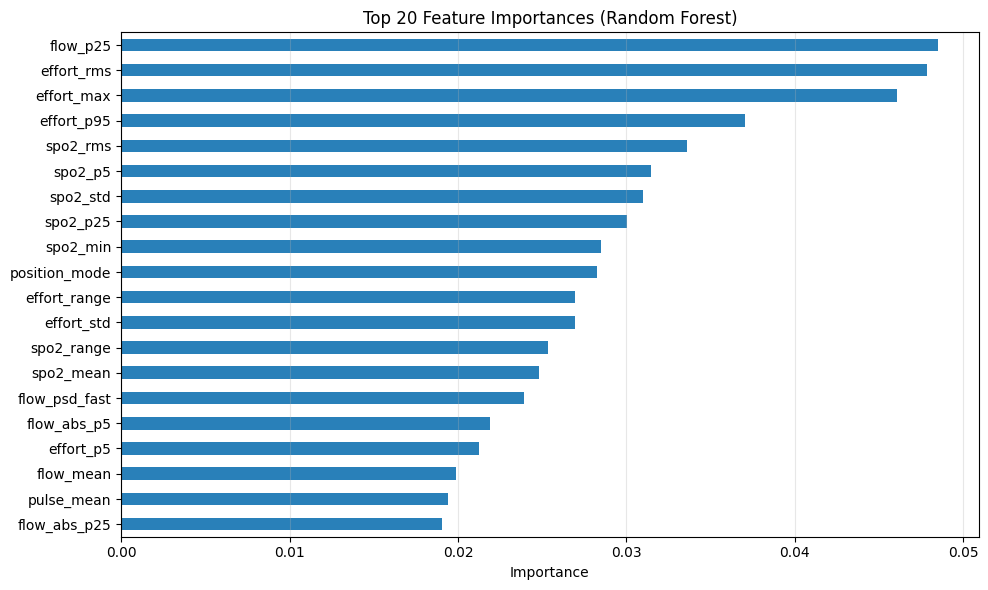

Saved: outputs/feature_importance.png


In [23]:
# Feature importance visualization (using a quick RF)
feat_cols = get_feature_columns(full_dataset)

X = full_dataset[feat_cols].values
y = full_dataset['severity_code'].values
valid_mask = y >= 0
X, y = X[valid_mask], y[valid_mask]

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

# Quick RF for feature importance
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42)
rf_quick.fit(X_imp, y)

importances = pd.Series(rf_quick.feature_importances_, index=feat_cols).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot.barh(ax=ax, color='#2980b9')
ax.set_title('Top 20 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150)
plt.show()
print("Saved: outputs/feature_importance.png")

## 3.2 OSA Severity Classification Model

In [27]:
# Stratified cross-validation
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score

le = LabelEncoder()
severity_labels = full_dataset['severity'][valid_mask].values

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight='balanced',
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline, X, y, cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'f1_macro': make_scorer(f1_score, average='macro'),
        'f1_weighted': make_scorer(f1_score, average='weighted'),
    },
    return_train_score=True,
)

print("=" * 50)
print("  Cross-Validation Results (5-fold stratified)")
print("=" * 50)
for metric, vals in cv_results.items():
    if metric.startswith('test'):
        print(f"  {metric:<22}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

  Cross-Validation Results (5-fold stratified)
  test_accuracy         : 0.868 ± 0.010
  test_f1_macro         : 0.857 ± 0.011
  test_f1_weighted      : 0.872 ± 0.010



=== Classification Report ==
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
        Mild       0.93      0.86      0.90      1153
    Moderate       0.67      0.87      0.76       704
      Severe       0.92      0.85      0.88      1671

    accuracy                           0.86      3528
   macro avg       0.63      0.65      0.63      3528
weighted avg       0.87      0.86      0.86      3528



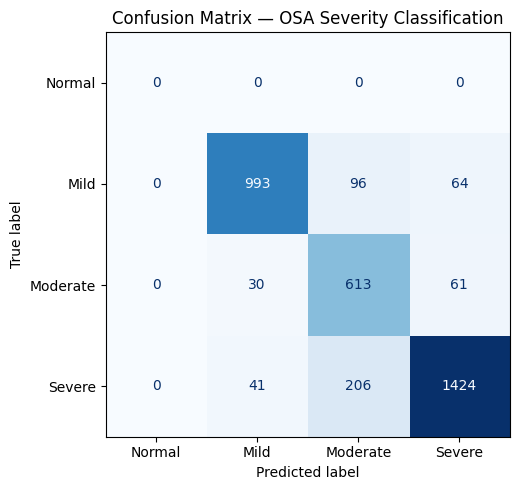

Saved: outputs/confusion_matrix.png


In [28]:
# Train final model on all data and show confusion matrix
from sklearn.model_selection import train_test_split

# Convert to plain numpy array to avoid PyArrow-backed ArrowExtensionArray incompatibility with sklearn
sev_labels_np = np.array(severity_labels, dtype=str)
X_train, X_test, y_train, y_test, sev_train, sev_test = train_test_split(
    X, y, sev_labels_np, test_size=0.25, stratify=y, random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

sev_order = ['Normal', 'Mild', 'Moderate', 'Severe']
code_order = [0, 1, 2, 3]

print("\n=== Classification Report ==")
print(classification_report(y_test, y_pred,
                             target_names=sev_order,
                             labels=code_order))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=code_order)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=sev_order)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — OSA Severity Classification')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("Saved: outputs/confusion_matrix.png")

In [29]:
# Patient-level prediction (majority vote over epochs)
print("\n=== Patient-Level Severity Prediction ===")
imputer_fit = pipeline.named_steps['imputer']
clf_fit = pipeline.named_steps['clf']

pred_rows = []
for p_data in all_patient_data:
    feat_df = extract_epoch_features(p_data)
    X_p = feat_df[feat_cols].values
    X_p_imp = imputer_fit.transform(X_p)
    preds = clf_fit.predict(X_p_imp)
    majority = int(np.bincount(preds.clip(0, 3)).argmax())
    severity_map = {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}
    pid = p_data['patient_id']
    gt_s = classify_severity(ahi_labels[pid])
    pred_rows.append({
        'Patient': pid,
        'GT AHI': round(ahi_labels[pid], 1),
        'GT Severity': gt_s,
        'Predicted Severity': severity_map[majority],
        'Match': '✓' if gt_s == severity_map[majority] else '✗'
    })

pred_df = pd.DataFrame(pred_rows)
correct = pred_df['Match'].value_counts().get('✓', 0)
print(f"Patient-level accuracy: {correct}/{len(pred_df)} ({correct/len(pred_df)*100:.0f}%)")
print()
print(pred_df.to_string(index=False))


=== Patient-Level Severity Prediction ===
Patient-level accuracy: 15/15 (100%)

    Patient  GT AHI GT Severity Predicted Severity Match
patient_001    45.5      Severe             Severe     ✓
patient_002    79.2      Severe             Severe     ✓
patient_003    13.1        Mild               Mild     ✓
patient_004    53.9      Severe             Severe     ✓
patient_005    10.5        Mild               Mild     ✓
patient_006    82.7      Severe             Severe     ✓
patient_007    37.4      Severe             Severe     ✓
patient_008    25.5    Moderate           Moderate     ✓
patient_009    27.7    Moderate           Moderate     ✓
patient_010     8.5        Mild               Mild     ✓
patient_011    24.4    Moderate           Moderate     ✓
patient_012    16.3    Moderate           Moderate     ✓
patient_013    14.3        Mild               Mild     ✓
patient_014    32.6      Severe             Severe     ✓
patient_015    41.7      Severe             Severe     ✓


## 3.3 Clinical Dashboard

Dashboard ถูกสร้างใน `src/dashboard.py` — รันด้วยคำสั่ง:

```bash
cd submissions/602016_ปัฐธกร
streamlit run src/dashboard.py
```

Dashboard ประกอบด้วย:
- **KPI Cards** — AHI, ODI, Mean SpO2, Nadir SpO2, T90, Severity
- **Signal Viewer** — interactive Plotly multi-channel plot พร้อม event overlays
- **Event Timeline** — scatter plot ของทุก events ตาม recording time
- **Positional Analysis** — pie chart เวลาต่อท่าและ AHI Supine vs Non-supine
- **Priority Triage Table** — ผู้ป่วยทุกรายเรียงตาม AHI

## 3.4 Final KPI Summary Report

In [30]:
# Clinical KPIs summary
print("=" * 65)
print("  Clinical KPI Summary — 15 Patients")
print("=" * 65)
kpi_cols = ['patient_id', 'GT AHI', 'Detected AHI', 'AHI Error',
             'ODI', 'Mean SpO2', 'Nadir SpO2', 'T90 (%)', 'Severity (GT)']
print(comp_df[kpi_cols].to_string(index=False))

print(f"\n  Mean AHI Error   : {comp_df['AHI Error'].mean():.2f} events/hr")
print(f"  Mean ODI         : {comp_df['ODI'].mean():.2f}")
print(f"  Mean SpO2 (all)  : {comp_df['Mean SpO2'].mean():.1f}%")
print(f"  Min Nadir SpO2   : {comp_df['Nadir SpO2'].min():.1f}%")

  Clinical KPI Summary — 15 Patients
 patient_id  GT AHI  Detected AHI  AHI Error    ODI  Mean SpO2  Nadir SpO2  T90 (%) Severity (GT)
patient_001   45.48         27.32      18.16  29.91      92.17        70.0    21.09        Severe
patient_002   79.16         69.92       9.24  66.41      90.44        58.0    33.31        Severe
patient_003   13.15         12.72       0.43   7.00      94.90        79.0     8.56          Mild
patient_004   53.88         46.01       7.87  50.68      90.91        73.0    31.07        Severe
patient_005   10.49          7.33       3.16   4.74      94.16        80.0     1.27          Mild
patient_006   82.69         90.90       8.21 100.93      79.83        50.0    73.61        Severe
patient_007   37.36         30.58       6.78  16.27      94.11        71.0     4.89        Severe
patient_008   25.48         27.75       2.27   6.56      95.83        87.0     0.10      Moderate
patient_009   27.73         10.77      16.96   7.82      92.98        82.0     8.

In [31]:
# Save full results
comp_df.to_csv(os.path.join(OUTPUT_DIR, 'full_results.csv'), index=False)
pred_df.to_csv(os.path.join(OUTPUT_DIR, 'model_predictions.csv'), index=False)
full_dataset.to_parquet(os.path.join(OUTPUT_DIR, 'feature_dataset.parquet'), index=False)

print("Outputs saved:")
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  outputs/{f}  ({size:,} bytes)")

print("\n=== Level 3 Complete ===")
print("\n🎉 All 3 Levels Done!")

Outputs saved:
  outputs/ahi_comparison.png  (53,246 bytes)
  outputs/ahi_report.csv  (1,083 bytes)
  outputs/ahi_report.md  (2,528 bytes)
  outputs/baseline_envelope.png  (311,050 bytes)
  outputs/clean_data_patient001.csv  (2,963,870 bytes)
  outputs/confusion_matrix.png  (37,314 bytes)
  outputs/correlation_matrix.png  (60,612 bytes)
  outputs/events_timeline.png  (44,109 bytes)
  outputs/feature_dataset.parquet  (3,135,834 bytes)
  outputs/feature_importance.png  (64,709 bytes)
  outputs/flow_spo2_scatter.png  (143,862 bytes)
  outputs/full_results.csv  (1,083 bytes)
  outputs/model_predictions.csv  (592 bytes)
  outputs/multichannel_patient001.png  (506,190 bytes)
  outputs/sqi_heatmap.png  (51,275 bytes)
  outputs/sqi_summary.csv  (1,041 bytes)

=== Level 3 Complete ===

🎉 All 3 Levels Done!
